# EV Battery Degradation & Fault Detection
This notebook walks through the project using real charging data from 49 electric vehicles. It has two models: a GAM that estimates how battery capacity fades with mileage, and an XGBoost model that flags vehicles likely to have a battery fault.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import clean_data, degradation_model, fault_model, make_charts

## Data
Each raw file is about 21 minutes of charging, recorded every 10 seconds. I combined these into one row per charging session.

In [2]:
clean_data.main()
sessions_df = clean_data.load_sessions()
sessions_df[["car", "mileage_km", "capacity_ah", "soc_start", "soc_end", "charge_current_a", "cell_spread_high_soc", "fault_label"]].head()

snippets: 176,327  sessions: 12,378  cars: 49


,car,mileage_km,capacity_ah,soc_start,soc_end,charge_current_a,cell_spread_high_soc,fault_label
0,500,11890.560,NaN,45.6,99.6,17.309771,0.021105,1
1,500,11979.264,NaN,79.6,100.0,15.879552,0.016236,1
2,500,12140.832,NaN,66.0,100.0,15.847744,0.017503,1
3,500,12276.000,NaN,74.4,100.0,16.007987,0.016766,1
4,500,12626.592,NaN,10.0,97.2,17.761673,0.021790,1


### Data quality
Real data is messy. These are the main issues the cleaning step handles:

In [3]:
clean_data.data_quality()

Snippets with no current (plugged in, idle)    70439
Snippets with faulty temperature sensors        1004
Odometer readings corrected                        4
Sessions with a capacity measurement            1239
Vehicles with a capacity measurement               8
Name: count, dtype: int64

Capacity was only measured for 8 of the 49 vehicles. I tried calculating it from current and state of charge, but it didn't match the dataset's values, so the degradation model only uses those 8 vehicles.

In [4]:
clean_data.coulomb_check()

353 sessions, correlation with the dataset's capacity: r = 0.06


### Vehicles with fault reports start being logged later
Faulty vehicles first show up in the data at around 11,000 km, compared to around 65 km for normal ones. A model that knew mileage could look accurate just from this, so mileage is never used as a feature in the fault model.

fault
0       65.472
1    10892.112
Name: first_km, dtype: float64

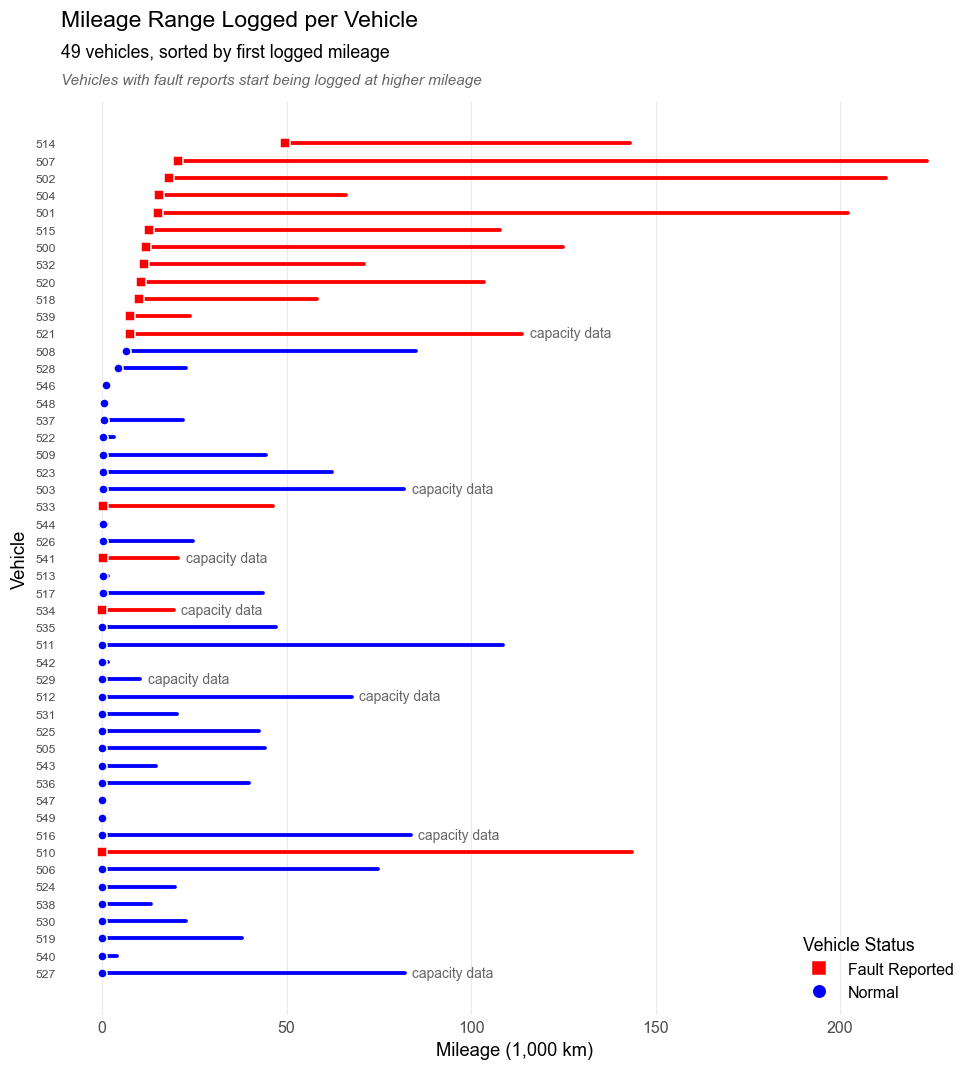

In [5]:
make_charts.vehicle_coverage(sessions_df);
sessions_df.groupby("car").agg(fault=("fault_label", "first"), first_km=("mileage_km", "min")).groupby("fault").first_km.median()

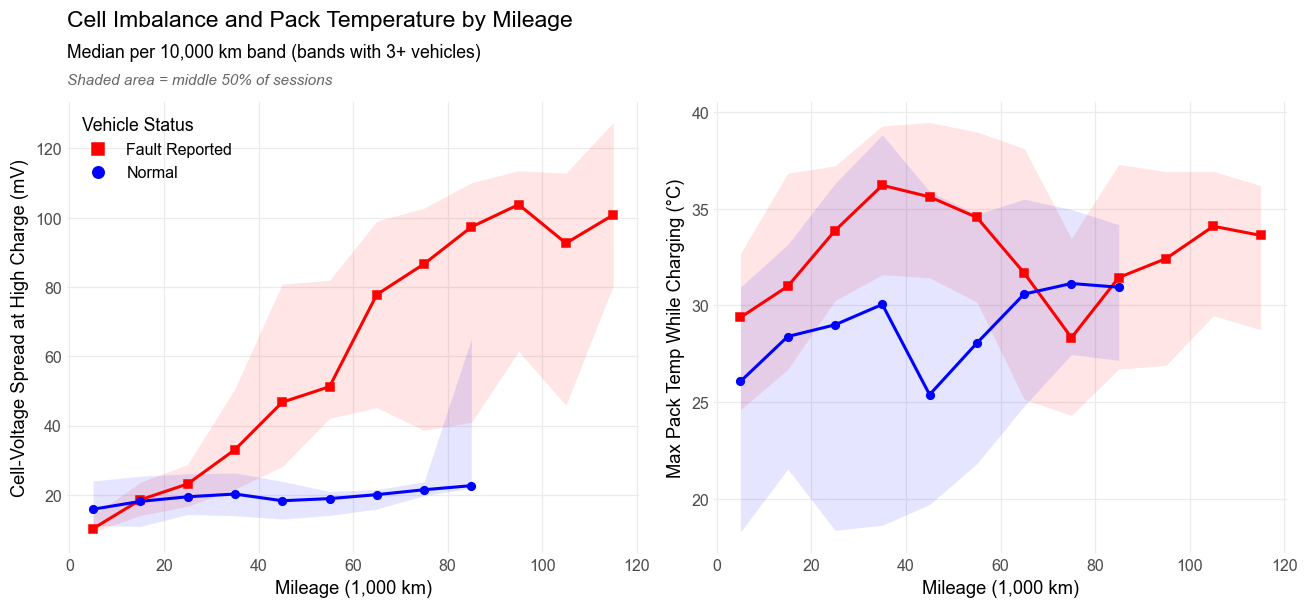

In [6]:
make_charts.signals_by_mileage(sessions_df);

The two groups look the same until about 20,000 km. After that, packs with fault reports show growing cell imbalance and run a few degrees hotter.

## Degradation Model (GAM)
Capacity retention compares each reading to the typical capacity of a new battery (the median below 5,000 km). Every version of the model is tested by leaving one vehicle out, so it's always predicting a car it hasn't seen.

In [7]:
degradation_results = degradation_model.run()
degradation_results["summary"]

{'capacity_readings': 1239,
 'outliers_removed': 39,
 'sessions_used': 1174,
 'vehicles': 8,
 'as_new_capacity_ah': 40.8393055,
 'model': 's(mileage) + f(vehicle)',
 'lambda': 100.0,
 'rmse_unseen_vehicles': 2.076200529767413,
 'rmse_fleet_average': 2.7421835412865243,
 'expected_retention_50k_km': 96.06379256933094,
 'expected_retention_100k_km': 94.11718190414445}

In [8]:
degradation_results["comparison_df"].round(3)

,model,vehicle_baseline,best_lambda,rmse,rmse_avg_per_vehicle
0,Mileage,True,100.0,2.076,2.346
1,Mileage,False,100.0,2.105,2.358
2,Mileage + charging temp,True,100.0,2.143,2.361
3,Mileage + charging temp,False,100.0,2.174,2.378
4,Mileage + charging temp + fast charging,True,100.0,2.157,2.386
5,Mileage + charging temp + fast charging,False,1000.0,2.160,2.403
6,Mileage + charging temp + depth of discharge,True,10.0,2.156,2.418
7,Mileage + charging temp + pack temp,True,100.0,2.169,2.455
8,All stress factors,True,100.0,2.298,2.488
9,Mileage + charging temp + pack temp,False,10000.0,2.218,2.495


Adding stress factors (fast charging, depth of discharge, temperature) didn't improve predictions on new vehicles, so the final model only uses mileage plus a baseline for each vehicle.

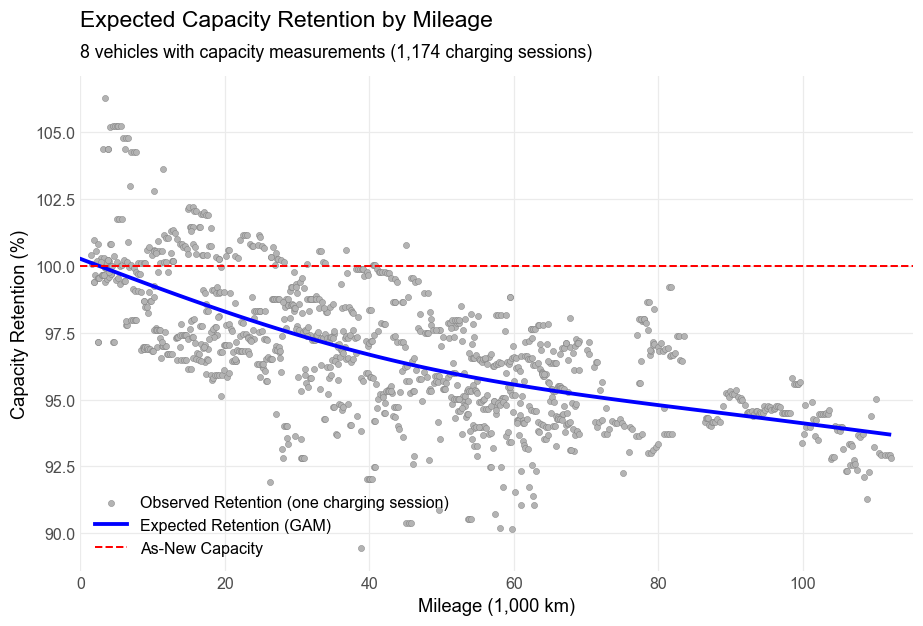

In [9]:
make_charts.expected_retention(degradation_results["capacity_df"], degradation_results["fade_curve_df"]);

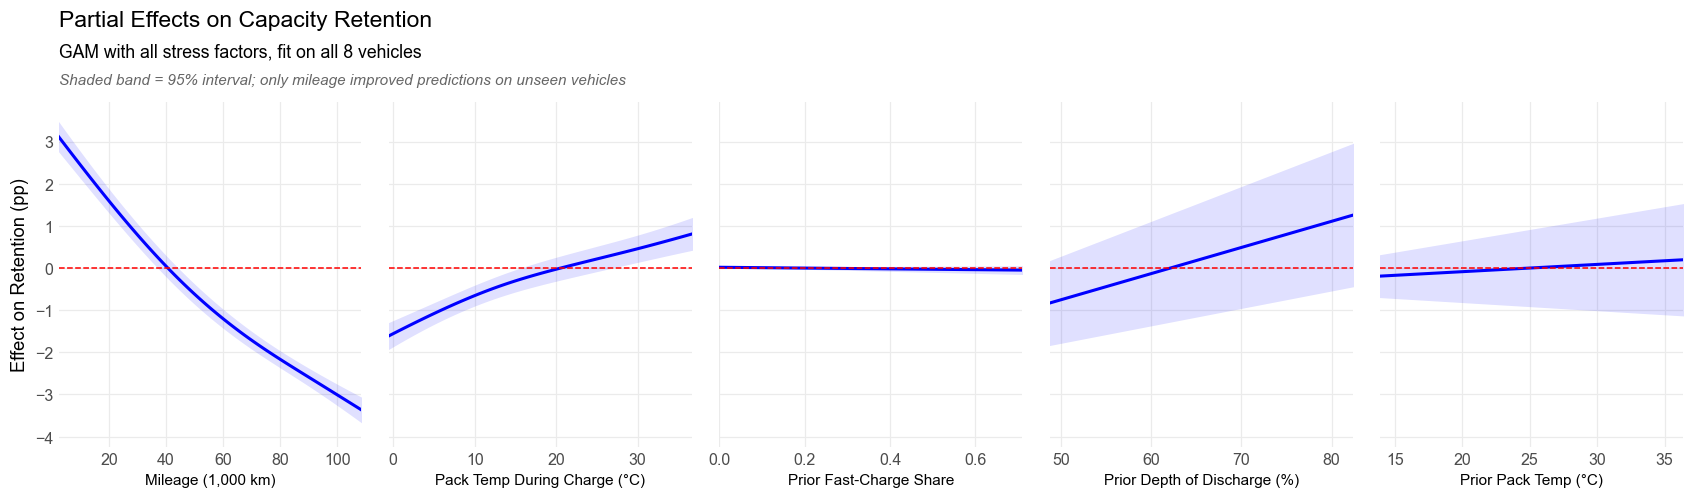

In [10]:
make_charts.partial_effects(degradation_results["stress_model"], degradation_results["capacity_df"], degradation_model.STRESS_FACTORS);

These show associations, not causes. Capacity reads lower on cold charges, and the depth of discharge trend most likely reflects which 8 vehicles happen to be in the data.

,car,fault_label,sessions,quality_score,ci_low,ci_high,blocks,trend_per_10k_km,flag
0,503,0,110,-1.46,-2.66,-0.13,16,0.50,worse than expected
1,512,0,187,-1.04,-1.70,-0.46,14,0.26,worse than expected
2,529,0,43,-0.90,-2.54,-0.23,3,NaN,insufficient data
3,527,0,245,-0.82,-1.11,-0.53,17,-0.16,worse than expected
4,521,1,296,-0.33,-0.70,0.01,17,-0.14,as expected
5,541,1,53,0.37,-2.11,4.12,5,-5.56,as expected
6,516,0,225,2.57,2.31,2.81,15,-0.00,better than expected
7,534,1,15,3.69,3.49,4.28,3,-0.82,insufficient data


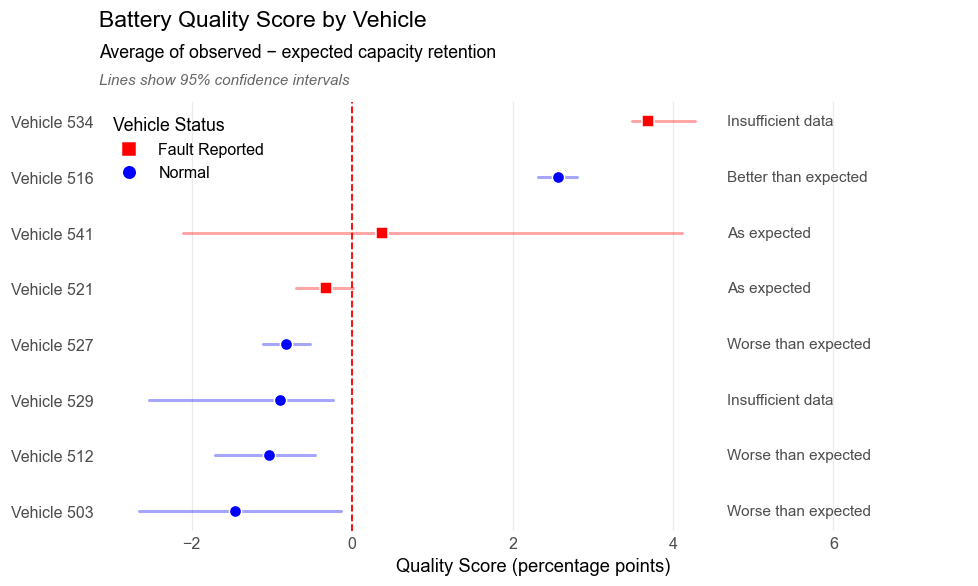

In [11]:
make_charts.quality_scores(degradation_results["scores_df"]);
degradation_results["scores_df"].round(2)

3 vehicles are aging worse than expected. Vehicle 541, which had a fault report, is losing capacity the fastest relative to expected (about 5.6 points per 10,000 km).

## Fault Model (XGBoost)
16 of the 49 vehicles have fire-incident or lithium-plating reports. The model scores each vehicle every 5,000 km using only its 40 most recent charging sessions. It's tested with cross-validation grouped by vehicle, so no vehicle is ever in both training and testing.

In [12]:
fault_results = fault_model.run()
auc_names = ["matched_mileage_auc", "matched_mileage_auc_spread_only", "pooled_auc", "pooled_auc_mileage_only"]
pd.DataFrame({name: fault_results["summary"][name] for name in auc_names}).T.round(3)

,mean,low,high
matched_mileage_auc,0.723,0.671,0.766
matched_mileage_auc_spread_only,0.686,0.686,0.686
pooled_auc,0.780,0.736,0.821
pooled_auc_mileage_only,0.694,0.650,0.724


Mileage alone scores 0.69 when all mileages are mixed together, which is why the main AUC only compares vehicles at the same checkpoint.

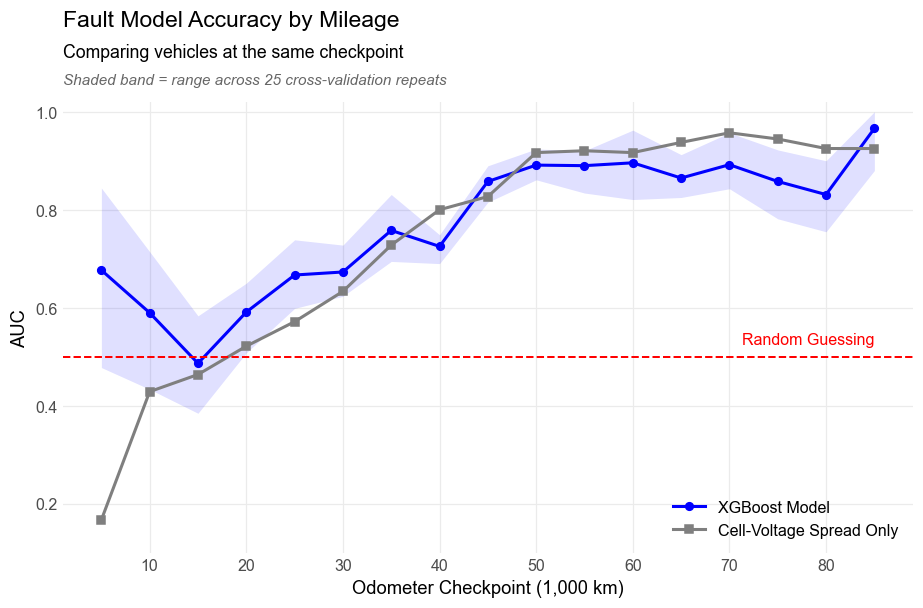

In [13]:
make_charts.auc_by_mileage(fault_results["auc_by_checkpoint_df"]);

The model is weak below about 20,000 km and much stronger from about 45,000 km on.

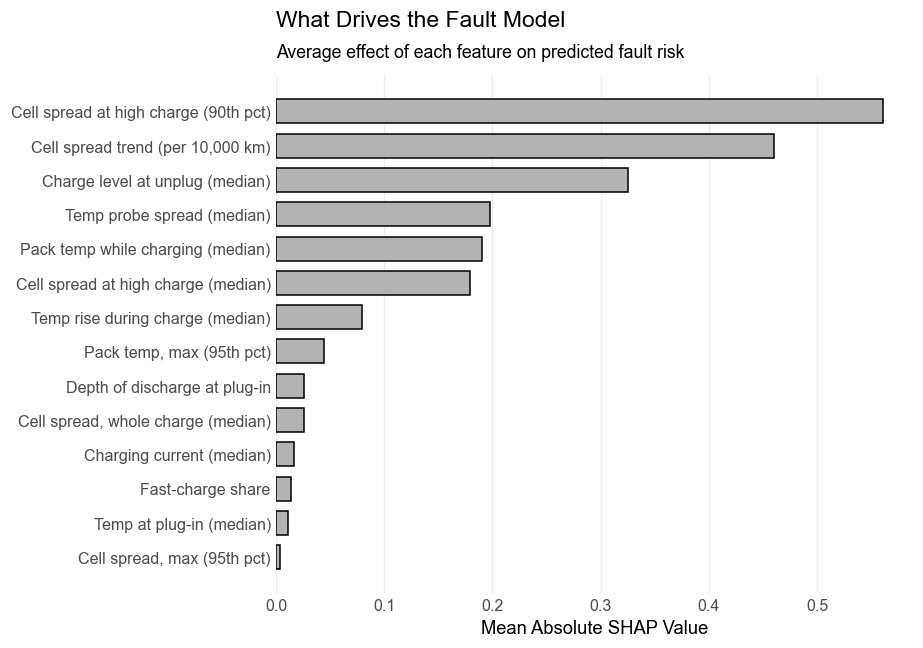

In [14]:
make_charts.feature_importance(fault_results["importance"]);

Cell-voltage spread (cells drifting out of balance) drives most of the predictions. Fast charging barely matters.

{'vehicles': 21,
 'with_fault_reports': 12,
 'top_5_with_fault_reports': 5,
 'top_10_with_fault_reports': 9}

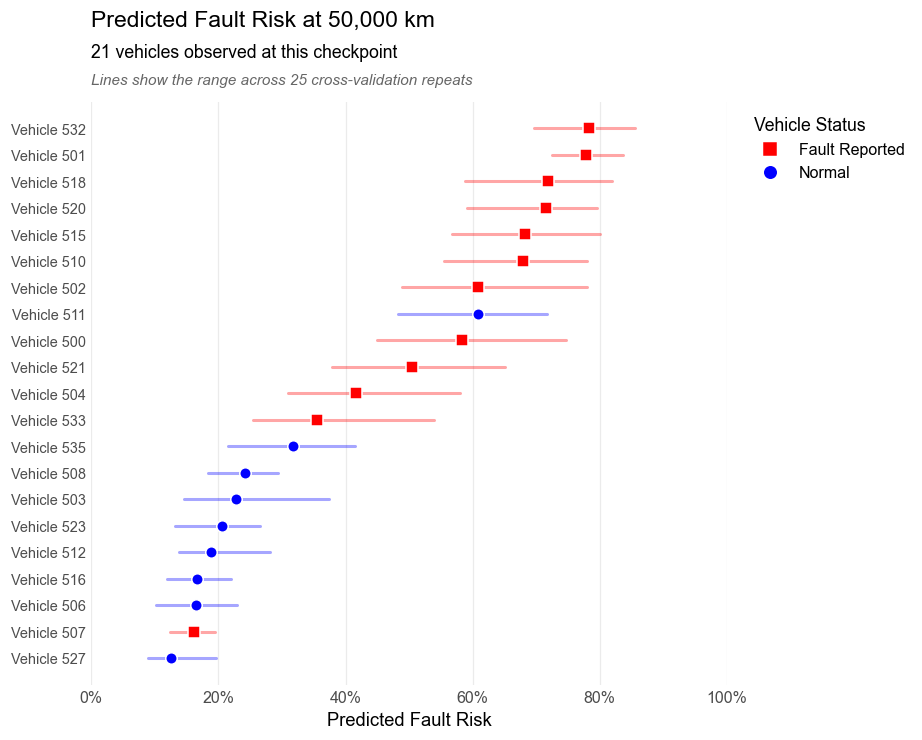

In [15]:
make_charts.risk_ranking(fault_results["ranking_df"]);
fault_results["summary"]["ranking_50k_km"]

At 50,000 km, all 5 of the highest-risk vehicles had fault reports, and 9 of the top 10 did (compared to 57% of vehicles overall). The one clear miss, vehicle 507, still had balanced cells at that point.

## Limitations
- Small sample: 49 vehicles, 16 with fault reports, and only 8 with capacity measurements
- No calendar dates, so the model can't predict when something will happen
- Fault reports have no date or type, and the dataset doesn't say whether data after a fault was removed
- Capacity is estimated by the battery management system and only measured on slow charges